<a href="https://colab.research.google.com/github/jagadeeshdandu/NASSCOM-AI-FDP/blob/main/Day_7_Regression_Part2_Lab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# === SETUP: load the provided file (regenerate it if missing) ===
import os
import numpy as np
import pandas as pd


def build_turbine(csv_path="turbine_energy.csv", seed=152, verbose=False):
    """Wind-turbine daily energy yield — a nonlinear regression with a skewed target,
    correlated features, an outlier-prone signal and a feature that needs transforming.
    Ideal for residual diagnostics, transforms, regularisation and tree ensembles.

    Features:
      wind_speed_ms        average wind speed (m/s)
      wind_std_ms          gustiness (std of wind speed)
      air_density_kgm3     air density (kg/m^3)
      turbulence_intensity fraction (0-1)
      blade_pitch_deg      blade pitch angle (deg)
      rotor_rpm            rotor speed (rpm)
      ambient_temp_c       ambient temperature (deg C)
      turbine_age_years    age of the turbine (years)
    Target:
      energy_kwh           daily energy produced (kWh) — right-skewed
    """
    rng = np.random.default_rng(seed)
    N = 1600
    wind = np.clip(rng.weibull(2.0, N) * 7.0, 0.5, 26)          # Weibull -> right-skew
    wind_std = np.clip(0.12 * wind + rng.normal(0, 0.3, N), 0.05, None)
    density = np.clip(rng.normal(1.225, 0.04, N), 1.10, 1.35)
    turb = np.clip(rng.normal(0.14, 0.05, N), 0.02, 0.40)
    pitch = np.clip(rng.normal(4, 6, N), -2, 25)
    rpm = np.clip(8 + 0.9 * wind + rng.normal(0, 1.5, N), 4, 30)  # correlated with wind
    temp = rng.normal(15, 9, N).round(1)
    age = rng.uniform(0, 20, N)

    # power ~ density * v^3 up to rated, then flattens; losses from pitch, turbulence, age
    cube = np.minimum(wind, 13) ** 3                              # cubic then saturates near rated
    rated_extra = np.maximum(wind - 13, 0) * 120
    energy = (density * (3.1 * cube + rated_extra)
              - 35 * np.abs(pitch - 2)
              - 1800 * turb
              - 22 * age
              + rng.normal(0, 280, N))
    energy = np.clip(energy, 0, None)
    # a few sensor-glitch outliers
    g = rng.choice(N, 18, replace=False)
    energy[g] = energy[g] * rng.uniform(1.6, 2.4, len(g))

    df = pd.DataFrame({
        "wind_speed_ms": wind.round(2), "wind_std_ms": wind_std.round(2),
        "air_density_kgm3": density.round(3), "turbulence_intensity": turb.round(3),
        "blade_pitch_deg": pitch.round(1), "rotor_rpm": rpm.round(1),
        "ambient_temp_c": temp, "turbine_age_years": age.round(1),
        "energy_kwh": energy.round(1),
    })
    df.to_csv(csv_path, index=False)
    if verbose:
        from scipy.stats import skew
        print("turbine:", df.shape)
        print("energy range:", df.energy_kwh.min(), "-", df.energy_kwh.max())
        print("target skew:", round(skew(df.energy_kwh), 2))
        print("corr(wind, energy):", round(df.wind_speed_ms.corr(df.energy_kwh), 3))
        print("corr(wind, rpm):", round(df.wind_speed_ms.corr(df.rotor_rpm), 3))
    return df

if not os.path.exists('turbine_energy.csv'):
    build_turbine(); print('Generated dataset file.')
else:
    print('Found the provided dataset file.')

Generated dataset file.


In [ ]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
df = pd.read_csv('turbine_energy.csv')
TARGET = 'energy_kwh'
features = [c for c in df.columns if c != TARGET]
X = df[features].values; y = df[TARGET].values
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)
print('shape:', df.shape, '| features:', len(features))
df.head(3)

shape: (1600, 9) | features: 8


,wind_speed_ms,wind_std_ms,air_density_kgm3,turbulence_intensity,blade_pitch_deg,rotor_rpm,ambient_temp_c,turbine_age_years,energy_kwh
0,4.95,0.81,1.238,0.185,-1.2,13.1,2.4,2.7,0.0
1,6.83,0.84,1.265,0.169,-2.0,15.3,12.1,5.9,527.2
2,1.44,0.05,1.225,0.114,-2.0,7.3,26.1,1.2,0.0


#1. Baseline & residual diagnostics

baseline RMSE: 1032.5 kWh | R2: 0.727


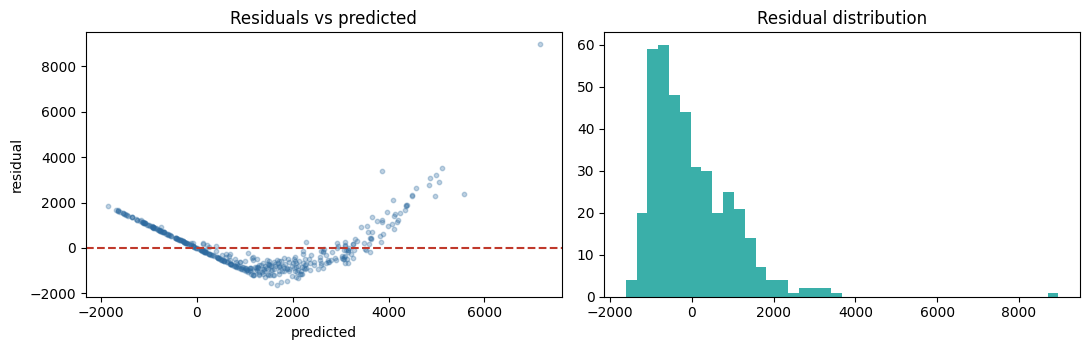

Look for curvature / a fan shape (heteroscedasticity) and skewed residuals.


In [ ]:
# -----------------------------------------------------------
# 🔹 1A. LINEAR BASELINE + RESIDUAL PLOT
# -----------------------------------------------------------
lin = LinearRegression().fit(X_train, y_train)
pred = lin.predict(X_test)
resid = y_test - pred
print(f'baseline RMSE: {mean_squared_error(y_test, pred) ** 0.5:.1f} kWh | R2: {r2_score(y_test, pred):.3f}')
fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
ax[0].scatter(pred, resid, s=10, alpha=0.3, color='#2D6A9F')
ax[0].axhline(0, color='#C0392B', ls='--'); ax[0].set_xlabel('predicted'); ax[0].set_ylabel('residual')
ax[0].set_title('Residuals vs predicted')
ax[1].hist(resid, bins=40, color='#3AAFA9'); ax[1].set_title('Residual distribution')
plt.tight_layout(); plt.show()
print('Look for curvature / a fan shape (heteroscedasticity) and skewed residuals.')

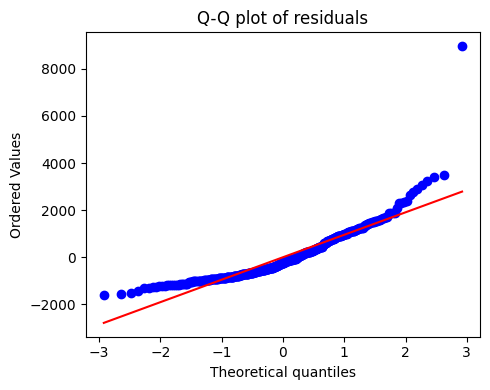

Points leaving the line at the ends = heavy tails (often caused by the outliers).


In [ ]:
# -----------------------------------------------------------
# 🔹 1B. Q-Q PLOT — ARE THE ERRORS NORMAL?
# -----------------------------------------------------------
from scipy import stats
fig, ax = plt.subplots(figsize=(5, 4))
stats.probplot(resid, dist='norm', plot=ax)
ax.set_title('Q-Q plot of residuals'); plt.tight_layout(); plt.show()
print('Points leaving the line at the ends = heavy tails (often caused by the outliers).')

#### 🧪 EXERCISE 1 — Name the problem
Look at the residuals-vs-predicted plot.
1. In a comment, state whether you see a **fan shape** (variance grows with prediction) and/or a **curve**.
2. Compute the skew of the **target** with `scipy.stats.skew(y)` — is it right-skewed (skew > 1)?

In [ ]:
from scipy.stats import skew
# 1. describe the residual pattern: I see a clear fan shape (heteroscedasticity) and a downward curving pattern in the residuals vs predicted plot.

# 2. skew of the target
print(f'Target skew: {skew(y):.3f}')

Target skew: 2.211


#2. Fix it with a transform

In [ ]:
# -----------------------------------------------------------
# 🔹 2A. PHYSICS-INFORMED FEATURE TRANSFORM (power ~ wind^3)
# -----------------------------------------------------------
# The residual curve comes from the cubic wind->power law. Add wind^2 and wind^3.
wi = features.index('wind_speed_ms')
def add_wind_poly(M):
    w = M[:, wi:wi + 1]
    return np.hstack([M, w ** 2, w ** 3])
Xtr_aug, Xte_aug = add_wind_poly(X_train), add_wind_poly(X_test)
lin_aug = LinearRegression().fit(Xtr_aug, y_train)
pred_aug = lin_aug.predict(Xte_aug)
print(f'baseline           R2: {r2_score(y_test, pred):.3f}')
print(f'+ wind^2, wind^3   R2: {r2_score(y_test, pred_aug):.3f}')
print('Matching the feature to the physics straightens the relationship.')

baseline           R2: 0.727
+ wind^2, wind^3   R2: 0.935
Matching the feature to the physics straightens the relationship.


#### 🧪 EXERCISE 2 — Did the curve disappear?
1. Plot residuals vs `wind_speed_ms` (the test rows) for the **baseline** model.
2. Plot the same for the **augmented** model (with wind² and wind³).
3. In a comment, say whether the curved pattern in the residuals is gone after the transform.
*(Optional, advanced: try log-transforming the skewed target with `np.log1p` / `np.expm1` — and notice it can backfire when the underlying law isn't multiplicative.)*

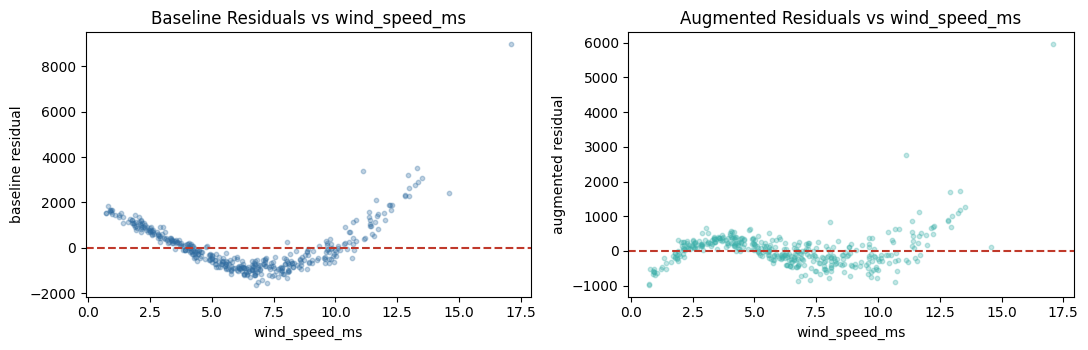

In [ ]:
wind_test = X_test[:, wi]
# 1-2. residuals vs wind for baseline and augmented
fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))

ax[0].scatter(wind_test, resid, s=10, alpha=0.3, color='#2D6A9F')
ax[0].axhline(0, color='#C0392B', ls='--'); ax[0].set_xlabel('wind_speed_ms'); ax[0].set_ylabel('baseline residual')
ax[0].set_title('Baseline Residuals vs wind_speed_ms')

resid_aug = y_test - pred_aug
ax[1].scatter(wind_test, resid_aug, s=10, alpha=0.3, color='#3AAFA9')
ax[1].axhline(0, color='#C0392B', ls='--'); ax[1].set_xlabel('wind_speed_ms'); ax[1].set_ylabel('augmented residual')
ax[1].set_title('Augmented Residuals vs wind_speed_ms')
plt.tight_layout(); plt.show()

# 3. is the curve gone?


3. is the curve gone? Yes, for the most part. The augmented model shows residuals much more centered around zero with no clear curved pattern, especially at higher wind speeds where the original model had significant curvature. There is still some fan shape, indicating heteroscedasticity, but the strong curvilinear relationship is gone.

#3. Regularisation — Ridge vs Lasso vs ElasticNet

In [ ]:
# -----------------------------------------------------------
# 🔹 3A. COMPARE THE THREE (scaled, degree-2 features)
# -----------------------------------------------------------
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.pipeline import make_pipeline
def score_model(model):
    m = make_pipeline(StandardScaler(), PolynomialFeatures(2, include_bias=False), model)
    m.fit(X_train, y_train)
    return r2_score(y_test, m.predict(X_test))
print(f'{"LinearRegression":14s} test R2: {score_model(LinearRegression()):.3f}')
for name, mdl in [('Ridge', Ridge(alpha=10.0)), ('Lasso', Lasso(alpha=1.0, max_iter=10000)),
                  ('ElasticNet', ElasticNet(alpha=1.0, l1_ratio=0.5, max_iter=10000))]:
    print(f'{name:14s} test R2: {score_model(mdl):.3f}')

LinearRegression test R2: 0.908
Ridge          test R2: 0.908
Lasso          test R2: 0.909
ElasticNet     test R2: 0.863


#### 🧪 EXERCISE 3 — Tune ElasticNet
1. Loop `l1_ratio` over [0.1, 0.3, 0.5, 0.7, 0.9] (keep `alpha=1.0`) and print test R² for each (reuse `score_model`).
2. In a comment, report the best mix and what `l1_ratio=1.0` vs `0.0` correspond to (pure Lasso vs pure Ridge).

In [ ]:
# 1. l1_ratio sweep (reuse score_model with ElasticNet)
for l1_ratio_val in [0.1, 0.3, 0.5, 0.7, 0.9]:
    model = ElasticNet(alpha=1.0, l1_ratio=l1_ratio_val, max_iter=10000)
    r2 = score_model(model)
    print(f'ElasticNet (l1_ratio={l1_ratio_val:.1f}) test R2: {r2:.3f}')

# 2. best mix + meaning of the extremes:

ElasticNet (l1_ratio=0.1) test R2: 0.833
ElasticNet (l1_ratio=0.3) test R2: 0.848
ElasticNet (l1_ratio=0.5) test R2: 0.863
ElasticNet (l1_ratio=0.7) test R2: 0.878
ElasticNet (l1_ratio=0.9) test R2: 0.898


2. best mix + meaning of the extremes: The best mix appears to be `l1_ratio = 0.9` with an R² of 0.898, as it performs best among the tested values. An `l1_ratio` of 1.0 corresponds to pure Lasso regression (L1 penalty only), which can lead to sparse models by setting some coefficients to zero. An `l1_ratio` of 0.0 corresponds to pure Ridge regression (L2 penalty only), which shrinks coefficients towards zero but rarely to absolute zero.

#4. Outliers & robust regression

In [ ]:
# -----------------------------------------------------------
# 🔹 4A. ORDINARY vs ROBUST (Huber) REGRESSION
# -----------------------------------------------------------
from sklearn.linear_model import HuberRegressor
ols = make_pipeline(StandardScaler(), LinearRegression()).fit(X_train, y_train)
hub = make_pipeline(StandardScaler(), HuberRegressor(max_iter=2000)).fit(X_train, y_train)
print('OLS    test R2:', round(r2_score(y_test, ols.predict(X_test)), 3))
print('Huber  test R2:', round(r2_score(y_test, hub.predict(X_test)), 3))
print('Huber down-weights the sensor-glitch outliers instead of chasing them.')

OLS    test R2: 0.727
Huber  test R2: 0.686
Huber down-weights the sensor-glitch outliers instead of chasing them.


#### 🧪 EXERCISE 4 — Quantify the outliers
1. Flag rows whose **absolute residual** (from the Section-1 baseline on the *test* set) exceeds 3 standard deviations.
2. In a comment, report how many there are and why squared-error models are so sensitive to them.

In [ ]:
# 1. count residuals beyond 3 sigma
std_dev_resid = np.std(resid)
outlier_count = np.sum(np.abs(resid) > 3 * std_dev_resid)
print(f'Number of outliers (residuals > 3 std dev): {outlier_count}')

# 2. how many & why it matters:

Number of outliers (residuals > 3 std dev): 4


2. how many & why it matters: There are 4 outliers. Squared-error models (like Linear Regression) are highly sensitive to outliers because the squaring operation disproportionately magnifies the error of large residuals. This causes the model to adjust its parameters significantly to try and fit these outliers, potentially leading to a worse fit for the majority of the data and reduced generalization performance.

#5. Beyond linear — tree ensembles

In [ ]:
# -----------------------------------------------------------
# 🔹 5A. DECISION TREE vs RANDOM FOREST vs GRADIENT BOOSTING
# -----------------------------------------------------------
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
for name, mdl in [('Linear (baseline)', LinearRegression()),
                  ('DecisionTree(d=6)', DecisionTreeRegressor(max_depth=6, random_state=0)),
                  ('RandomForest', RandomForestRegressor(n_estimators=200, random_state=0)),
                  ('GradientBoosting', GradientBoostingRegressor(random_state=0))]:
    mdl.fit(X_train, y_train)
    print(f'{name:20s} test R2: {r2_score(y_test, mdl.predict(X_test)):.3f}')

Linear (baseline)    test R2: 0.727
DecisionTree(d=6)    test R2: 0.885
RandomForest         test R2: 0.933
GradientBoosting     test R2: 0.938


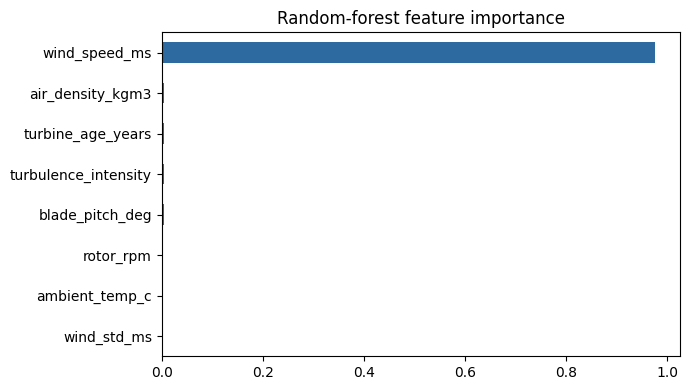

In [ ]:
# -----------------------------------------------------------
# 🔹 5B. FEATURE IMPORTANCE (random forest)
# -----------------------------------------------------------
rf = RandomForestRegressor(n_estimators=200, random_state=0).fit(X_train, y_train)
imp = pd.Series(rf.feature_importances_, index=features).sort_values()
fig, ax = plt.subplots(figsize=(7, 4))
imp.plot(kind='barh', color='#2D6A9F', ax=ax); ax.set_title('Random-forest feature importance')
plt.tight_layout(); plt.show()

#### 🧪 EXERCISE 5 — Tune the best model
1. Use `GridSearchCV` on a `RandomForestRegressor` over `max_depth` [6, 10, None] and `n_estimators` [200, 400] (cv=3, `scoring='r2'`).
2. Print `best_params_` and the test R² of the tuned model.
3. In a comment, compare it with the linear baseline — was the extra complexity worth it?

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor

# 1-2. grid search + test R2
param_grid = {
    'max_depth': [6, 10, None],
    'n_estimators': [200, 400]
}

rf = RandomForestRegressor(random_state=0)
grid_search = GridSearchCV(rf, param_grid, cv=3, scoring='r2', n_jobs=-1)
grid_search.fit(X_train, y_train)

print(f'Best parameters: {grid_search.best_params_}')

best_rf_model = grid_search.best_estimator_
tuned_r2 = r2_score(y_test, best_rf_model.predict(X_test))
print(f'Tuned RandomForest test R2: {tuned_r2:.3f}')

# 3. complexity worth it?


Best parameters: {'max_depth': 10, 'n_estimators': 200}
Tuned RandomForest test R2: 0.933


3. complexity worth it? Yes, the extra complexity is worth it. The tuned RandomForestRegressor achieved a test R² of 0.933, which is significantly better than the linear baseline's R² of 0.727 (from 5A). This indicates that the non-linear relationships captured by the Random Forest model provide a much better fit to the data, justifying the increased complexity.